<a href="https://colab.research.google.com/github/spirosChv/neuro208/blob/main/practicals/synapses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# @title Make nicer plots -- Execute this cell
def mystyle():
  """
  Create custom plotting style.

  Returns
  -------
  my_style : dict
      Dictionary with matplotlib parameters.

  """
  # color pallette
  style = {
      # Use LaTeX to write all text
      "text.usetex": False,
      "font.family": "DejaVu Sans",
      "font.weight": "bold",
      # Use 16pt font in plots, to match 16pt font in document
      "axes.labelsize": 16,
      "axes.titlesize": 20,
      "font.size": 16,
      # Make the legend/label fonts a little smaller
      "legend.fontsize": 14,
      "xtick.labelsize": 14,
      "ytick.labelsize": 14,
      "axes.linewidth": 2.5,
      "lines.markersize": 10.0,
      "lines.linewidth": 2.5,
      "xtick.major.width": 2.2,
      "ytick.major.width": 2.2,
      "axes.labelweight": "bold",
      "axes.spines.right": False,
      "axes.spines.top": False
  }

  return style


plt.style.use("seaborn-colorblind")
plt.rcParams.update(mystyle())

## Adaptive Exponential Integrate-and-Fire neuronal (aEIF) model

\begin{align}
C_m \frac{dV}{dt} &= -g_L (V-E_L) + g_L \Delta_T \text{exp} \left( \frac{V-V_T}{\Delta_T} \right) - w + I_e + I_{syn} \\
\tau_w \frac{dw}{dt} &= \alpha (V-E_L) - w
\end{align}

- where $C_m$ is the membrane capacitance, $g_L$ and $E_L$ are the leak conductance and reversal potential, reespectively.

- $\Delta_T$ controls the sharpness of action potential initiation (typical values $ \sim 1 mV$ for pyramidal neurons), $V_T$ denotes the intrinsic membrane potential threshold. Once the membrane potential crosses $V_{T}$, it diverges to infinity in finite time. In numerical simulation the integration is stopped if the membrane potential hits an arbitrary threshold $V_{peak}$ (much larger than $V_{T}$) at which the membrane potential is reset to a value $V_r$.

- $\tau_w$ is the time constant and $\alpha$ represents the level of **subthreshold adaptation**. At each firing time, the variable $w$ is increased by anamount $b$, which accounts for **spike-triggered adaptation**.

Spike mechanism:

\begin{equation}
\text{if } V \ge V_{peak} \text{ then } V → V_r, w → w + b
\end{equation}

### Synapses in derivative form

\begin{equation}
g_{syn}(t) = \bar{g}_{syn} \left( \text{exp} \left( -\frac{t-t_{sp}}{\tau_d} \right) - \text{exp} \left( -\frac{t-t_{sp}}{\tau_r} \right) \right)
\end{equation}

In dynamical systems, this is translated into:

\begin{align}
\frac{dg_{syn}}{dt} &= -\frac{g_{syn}}{\tau_d} + x_{syn}\\
\frac{dx_{syn}}{dt} &= -\frac{x_{syn}}{\tau_r}\\
\end{align}

At every presynaptic spike: $x_{syn} += 1\cdot f$, where $f$ is a normalization factor that sets the maximum $g_{syn}$ to $1$.

In [3]:
# Simulation parameters
T = 1000  # ms
dt = 0.01  # ms
steps = int(T/dt)
t_vec = np.linspace(0, T, steps+1)

In [4]:
# Model Parameters
C = 300  # membrane capacitance in pF
gL = 15  # leaky conductance in nS
EL = -70  # leaky reversal potential in mV

VT = -54  # threshold in mV
DeltaT = 2  # AP sharpness (slope factor) in mV
Vr = -80  # reset in mV
Vpeak = 20 # peak potential (detection limit) in mV

# Adaptation
tau_w = 144 # adaptation time constant in ms
alpha = 4  # subthreshold adaptation in nS
b = 80.5  # spike-triggered adaptation in pA

# Refractory period
tref = 20  # refractory period in ms

In [5]:
# Synaptic parameters
pre_spikes = [100]  # in ms

tau_rise = 50  # rise time in ms
tau_decay = 150  # decay time in ms
g_bar = 1  # maximum conductance in nS
E_syn = 0  # synaptic reversal potential in mV

In [6]:
def normalize(tau1, tau2):
  """
  Normalized synaptic conductance.

  Args:
    tau1 : float
      The rise time constant.
    tau2: float
      The decay time constant.
  ---
  Returns:
    1/peak : float
      The normalization factor, which is the g(tpeak).
  """
  tpeak = (tau1*tau2)/(tau2 - tau1) * np.log(tau2/tau1)
  peak = (np.exp(-tpeak/tau2) - np.exp(-tpeak/tau1))*(tau1*tau2)/(tau2 - tau1)
  return 1/peak

In [7]:
normalize(tau_rise, tau_decay)

0.034641016151377546

In [8]:
# Membrane Voltage (mV)
V = np.zeros((len(t_vec), ))
V[0] = EL  # initialization at EL

# Adaptation current (pA)
w = np.zeros((len(t_vec), ))
w[0] = 0  # initialization at 0

# Synaptic conductance (nS)
gsyn = np.zeros((len(t_vec), ))
gsyn[0] = 0  # initialization at 0

# Synaptic rise variable (nS)
xsyn = np.zeros((len(t_vec), ))
xsyn[0] = 0  # initialization at 0

# Synaptic current (pA)
Isyn = np.zeros((len(t_vec), ))

# Helper variables
tspike = [-1]
flag = True

for n in range(steps):

  # Compute `Isyn[n]`
  Isyn[n] = gsyn[n]*(V[n] - E_syn)
  
  # Compute `dV` and update `V[n+1]`
  dV = (-gL*(V[n]-EL) + gL*DeltaT*np.exp((V[n]-VT)/DeltaT) - w[n] - Isyn[n])/C
  V[n+1] = V[n] + dt*dV
  
  # Compute `dw` and update `w[n+1]`
  dw = (alpha*(V[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*dw

  # Compute `dgsyn` and `dxsyn` and update `gsyn[n+1]` and `xsyn[x+1]`
  dgsyn = -gsyn[n]/tau_decay + xsyn[n]
  dxsyn = -xsyn[n]/tau_rise
  gsyn[n+1] = gsyn[n] + dt*dgsyn
  xsyn[n+1] = xsyn[n] + dt*dxsyn

  # Spike mechanism
  if V[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    xsyn[n+1] += g_bar*normalize(tau_rise, tau_decay)

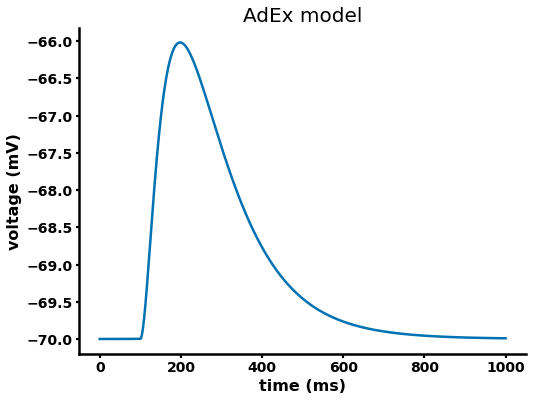

In [9]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.title('AdEx model')
plt.show()

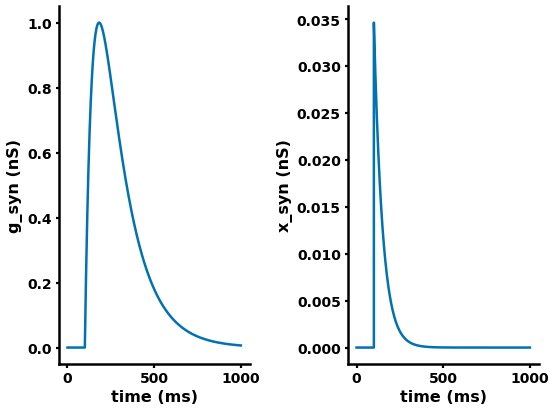

In [10]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(t_vec, gsyn)
plt.xlabel('time (ms)')
plt.ylabel('g_syn (nS)')
plt.subplot(1, 2, 2)
plt.plot(t_vec, xsyn)
plt.xlabel('time (ms)')
plt.ylabel('x_syn (nS)')

plt.tight_layout()
plt.show()

In [11]:
np.max(gsyn)

1.0000549362315485

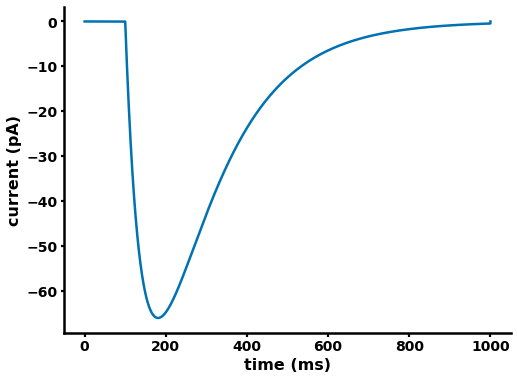

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn)
plt.xlabel('time (ms)')
plt.ylabel('current (pA)')
plt.show()

## Dynamic synapses

# Section 2: Short-term synaptic plasticity


*Estimated timing to here from start of tutorial: 45 min*

Above, we modeled synapses with fixed weights. Now we will explore synapses whose weight change in some input conditions. 

Short-term plasticity (STP) is a phenomenon in which synaptic efficacy changes over time in a way that reflects the history of presynaptic activity. Two types of STP, with opposite effects on synaptic efficacy, have been experimentally observed. They are known as Short-Term Depression (STD) and Short-Term Facilitation (STF).

The mathematical model (_for more information see [here](http://www.scholarpedia.org/article/Short-term_synaptic_plasticity)_) of STP is based on the concept of a limited pool of synaptic resources available for transmission ($R$), such as, for example, the overall amount of synaptic vesicles at the presynaptic terminals. The amount of presynaptic resource changes in a dynamic fashion depending on the recent history of spikes. 

Following a presynaptic spike, (i) the fraction $u$ (release probability) of the available pool to be utilized increases due to spike-induced calcium influx to the presynaptic terminal, after which (ii) $u$ is consumed to increase the post-synaptic conductance. Between spikes, $u$ decays back to zero with time constant $\tau_f$ and $R$ recovers to 1 with time constant $\tau_d$. In summary, the dynamics of excitatory (subscript $E$) STP are given by:

\begin{align}
\frac{du}{dt} &= -\frac{u}{\tau_f} + U_0(1-u^-)\delta(t-t_{\rm sp}) \\
\frac{dx}{dt} &= \frac{1-x}{\tau_d} - u^+ x^- \delta(t-t_{\rm sp}) \\
\frac{dg_E(t)}{dt} &= -\frac{g_E}{\tau_E} + \bar{g}_E u^+ x^- \delta(t-t_{\rm sp})
\end{align}

- $U_0$ is a constant determining the increment of $u$ produced by a spike. $u^-$ and $x^-$ denote the corresponding values just before the spike arrives, whereas $u^+$ refers to the moment right after the spike.
- $\bar{g}_E$ denotes the maximum excitatory conductane, and $g_E(t)$ is calculated for all spiketimes $k$, and decays over time with a time constant $\tau_{E}$.

Similarly, one can obtain the dynamics of inhibitory STP (i.e., by replacing the subscript $E$ with $I$).

The interplay between the dynamics of $u$ and $x$ determines whether the joint effect of $u \cdot x$ is dominated by *depression* or *facilitation*.

- In the parameter regime of $\tau_d \gg \tau_f$  and for large $U_0$, an initial spike incurs a large drop in $R$ that takes a long time to recover; therefore, the synapse is STD-dominated.
- In the regime of $\tau_d \ll \tau_f$ and for small $U_0$, the synaptic efficacy is increased gradually by spikes, and consequently, the synapse is STF-dominated.

This phenomenological model successfully reproduces the kinetic dynamics of depressed and facilitated synapses observed in many cortical areas.

- for STD, `U0=0.5, tau_d=100., tau_f=50.`

- for STP, `U0=0.2, tau_d=100., tau_f=750.`

In [13]:
# Synaptic parameters
pre_spikes = [100, 150, 200, 250, 300, 350]  # list with presynaptic spikes (ms)

tau_rise = 2  # rise time (ms)
tau_decay = 10  # decay time (ms)
g_bar = 1  # maximum conductance (nS)
E_syn = 0  # synaptic reversal potential (mV)

In [14]:
U0 = 0.2  # synaptic release probability at rest, unitless
tau_d = 100  # synaptic depression time constant of x (ms)
tau_f = 750  # synaptic facilitation time constant of u (ms)  

In [15]:
# Membrane Voltage (mV)
V = np.zeros((len(t_vec), ))
V[0] = EL  # initialization at EL

# Adaptation current (pA)
w = np.zeros((len(t_vec), ))
w[0] = 0  # initialization at 0

# Synaptic conductance (nS)
gsyn = np.zeros((len(t_vec), ))
gsyn[0] = 0  # initialization at 0

# Synaptic rise variable (nS)
xsyn = np.zeros((len(t_vec), ))
xsyn[0] = 0  # initialization at 0

# Synaptic release probability (unitless)
u = np.zeros((len(t_vec), ))
u[0] = 0  # initialization at 0

# Resourses available (a.u.)
x = np.zeros((len(t_vec), ))
x[0] = 1  # initialization at 1

# Synaptic current
Isyn = np.zeros((len(t_vec), ))

# Helper variables
tspike = [-1]
flag = True

for n in range(steps):

  # Compute `Isyn[n]`
  Isyn[n] = gsyn[n]*(V[n] - E_syn)
  
  # Compute `dV` and update `V[n+1]`
  dV = (-gL*(V[n]-EL) + gL*DeltaT*np.exp((V[n]-VT)/DeltaT) - w[n] - Isyn[n])/C
  V[n+1] = V[n] + dt*dV
  
  # Compute `dw` and update `w[n+1]`
  dw = (alpha*(V[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*dw
  
  # Compute `du` and update the `u[n+1]`
  du = -u[n]/tau_f
  u[n+1] = u[n] + dt*du
  
  # Compute `dx` and update `x[n+1]`
  dx = (1.0 - x[n])/tau_d
  x[n+1] = x[n] + dt*dx

  # Compute `dgsyn`, `dxsyn` and update `gsyn[n+1]` and `xsyn[n+1]`
  dgsyn = -gsyn[n]/tau_decay + xsyn[n]
  dxsyn = -xsyn[n]/tau_rise
  gsyn[n+1] = gsyn[n] + dt*dgsyn
  xsyn[n+1] = xsyn[n] + dt*dxsyn

  # Spike mechanism
  if V[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    # u[n+1] denotes the u^+, while the u[n] denotes the u^-. Similarly with x.
    u[n+1] += U0*(1.0-u[n])  # calculate the release probability
    x[n+1] -= u[n+1]*x[n]  # calculate the available resourses
    xsyn[n+1] += g_bar*normalize(tau_rise, tau_decay)*x[n]*u[n+1]

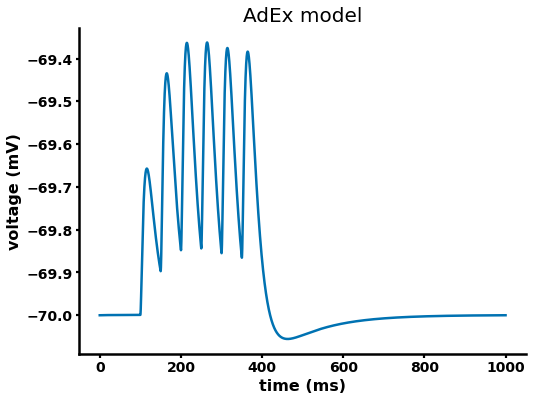

In [16]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.title('AdEx model')
plt.show()

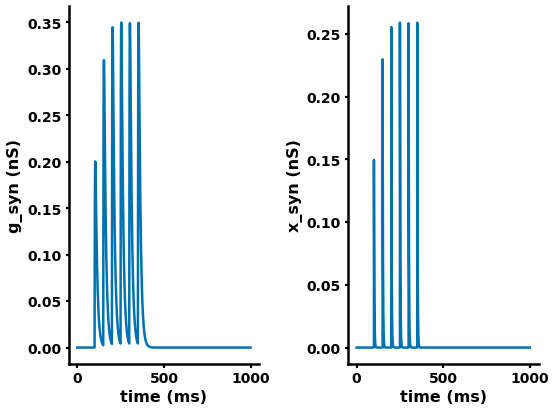

In [17]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(t_vec, gsyn)
plt.xlabel('time (ms)')
plt.ylabel('g_syn (nS)')
plt.subplot(1, 2, 2)
plt.plot(t_vec, xsyn)
plt.xlabel('time (ms)')
plt.ylabel('x_syn (nS)')

plt.tight_layout()
plt.show()

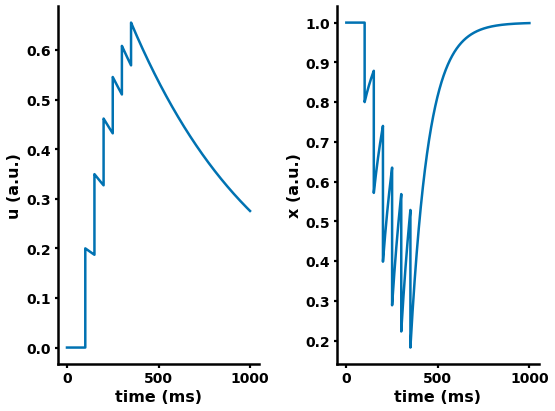

In [18]:
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.plot(t_vec, u)
plt.xlabel('time (ms)')
plt.ylabel('u (a.u.)')
plt.subplot(1, 2, 2)
plt.plot(t_vec, x)
plt.xlabel('time (ms)')
plt.ylabel('x (a.u.)')

plt.tight_layout()
plt.show()

## $\text{GABA}_\text{B}$ receptors

Based on [Thomson and Destexhe, 1999](https://doi.org/10.1016/s0306-4522(99)00021-4).

We will simulate the diffusion of GABA in the extracellular space, i.e., synaptic cleft. The GABA uptake is simulated based on the following scheme (i.e., reactions)

\begin{align}
T + U \underset{k_{-1}}{\stackrel{k_1}{\rightleftharpoons}} B \\
B {\stackrel{k_2}{\rightarrow}} U + GABA_\text{i}
\end{align}

- The first step describes the reversible binding of GABA to the unbound transporter ($U$), leading to bound transporter ($B$). 

- The second step represents the irreversible translocation of $GABA$ into the intracellular space ($GABA_\text{i}$)

The reactions, can be translated into differential equations:

\begin{align}
\frac{d[T]}{dt} &= -k_1 \cdot [T] \cdot (B_m - [B]) + k_{-1} \cdot [B] - \frac{[T]}{\tau_D} \\
\frac{d[B]}{dt} &= k_1 \cdot [T] \cdot (B_m - [B]) - (k_{-1}+k_2) \cdot [B]\\
\end{align}

where $[T]$ is the concentration of GABA, $[B]$ the concentartion of bound transporter, $k_1$ and $k_{-1}$ the forward ($\text{ms}^{-1} \text{mM}^{-1}$) and backword binding rate ($\text{ms}^{-1}$) of GABA to/of the transporter, $k_2$ the translocation of GABA rate ($\text{ms}^{-1}$), $B_m$ the total extracellular concentration of available transporter ($\text{mM}$), and $\tau_D$ is the decay time constant of the transmitter concentration ($\text{ms}$). The quantity $B_m-[B]$ represents the $[U]$.

The activation of $\text{GABA}_\text{B}$ responses are simulated using the following kinetic equations:

\begin{align}
R_0 + T \rightleftharpoons R \\
R + G_0 \rightleftharpoons RG \rightarrow R+G \\
G \rightarrow G_0 \\
K_0 + nG \underset{d_2}{\stackrel{d_1}{\rightleftharpoons}} K
\end{align}

- $GABA$ binds to the inactive form of the $\text{GABA}_\text{B}$ receptor ($R_0$), leading to the activated form of the receptor ($R$) – reaction 1
- $R$ catalyzes the formation of active G-proteins ($G$) from their inactive form ($G_0$) – reaction 2
- Activated G-proteins ($G$) is hydrolyzed to its inactive form ($G_0$) – reaction 3
- $n$ activated G-proteins bind to the closed form of the K+ channel ($K_0$), leading to opening of K+ channels ($K$)

The correspodning differential equations are:


\begin{align}
\frac{d[R]}{dt} &= K_1 \cdot [T] \cdot (1 - [R]) - K_2 \cdot [R] \\
\frac{d[G]}{dt} &= K_3 \cdot [R] - K_4 \cdot [G] \\
I_{{\text{GABA}}_\text{B}} &= \bar{\text{g}}_{{\text{GABA}}_\text{B}} \frac{G^n}{[G]^n + K_D} (V-E_K)
\end{align}

where $[R]$ denotes the fraction of activated receptors, $[G]$ the normalized concentration of activated G-protein, $K_1$ the forward binding rate to the  receptor ($\text{ms}^{-1} \text{mM}^{-1}$), $K_2$ the backward (unbinding) rate of the receptor ($\text{ms}^{-1}$), $K_3$ the rate of G-Protein production ($\text{ms}^{-1}$) and $K_4$ is the rate of G-protein decay ($\text{ms}^{-1}$). $K_D$ is the dissociation constant ($d_2/d_1$) of the binding of $G$ on the $\text{K}^+$ channels ($d_1$ and $d_2$ are the rate constants of binding and unbinding of G-proteins onto $\text{K}^+$ channels), and $n$ denotes the number of binding sites of G-protein on the $\text{K}^+$ channels.

<br>

$^{\dagger}$For more information about translating chemical reactions into differential equations, you can see [here](https://doi.org/10.1007/978-0-387-09680-3_18) and [here](https://en.wikipedia.org/wiki/Michaelis%E2%80%93Menten_kinetics).

In [19]:
# Simulation parameters
T = 1000  # ms
dt = 0.1  # ms
steps = int(T/dt)
t_vec = np.linspace(0, T, steps+1)

In [20]:
# Synaptic parameters
pre_spikes = [100]  # list with presynaptic spikes (ms)

g_bar = 1  # maximum conductance (nS)
E_syn = -95  # synaptic reversal potential (mV)

tauD = 10	 # decay of transmitter concentration (ms)
K1 = 0.18	 # forward binding rate to receptor (ms-1 mM-1)
K2 = 0.0096  # backward (unbinding) rate of receptor (ms-1)
K3 = 0.19  # rate of G-protein production (ms-1)
K4 = 0.060  # rate of G-protein decay (ms-1)
KD = 17.83  # dissociation constant of the binding of 𝐺 on the K+ channels
nbs	= 1  # number of binding sites of G-protein on K+
k1 = 3	 # forward binding rate to transporter (ms-1 mM-1)
k_1	= 0.1  # backward (unbinding) rate of transporter (ms-1)
k2	= 0.02  # clearance of GABA (ms-1)
Bm = 1  # maximum binding capacity of transporter (mM)
Tmax = 1  # max concentration per spike (mM)
gbar = 1  # max conductance (nS)

In [21]:
# Membrane voltage (mV)
V = np.zeros((len(t_vec), ))
V[0] = EL  # initialization at EL

# Adaptation current (pA)
w = np.zeros((len(t_vec), ))
w[0] = 0  # initialization at 0

# Transmitter concentration (mM)
Tvar = np.zeros((len(t_vec), ))
Tvar[0] = 0  # initialization at 0

# Bound transporter concentration (mM)
Bvar = np.zeros((len(t_vec), ))
Bvar[0] = 0  # initialization at 0

# Receptor availability (unitless)
Rvar = np.zeros((len(t_vec), ))
Rvar[0] = 0  # initialization at 0

# G-protein concentration (unitless)
Gvar = np.zeros((len(t_vec), ))
Gvar[0] = 0  # initialization at 0

# Synaptic current
Isyn = np.zeros((len(t_vec), ))

# Helper variables
tspike = [-1]
flag = True

for n in range(steps):

  # Calculate `Isyn[n]`
  Isyn[n] = gbar*(Gvar[n]**nbs/(Gvar[n]**nbs+KD))*(V[n] - E_syn)
  
  # Compute `dV` and update `V[n+1]`
  dV = (-gL*(V[n]-EL) + gL*DeltaT*np.exp((V[n]-VT)/DeltaT) - w[n] - Isyn[n])/C
  V[n+1] = V[n] + dt*dV
  
  # Compute `dw` and update `w[n+1]`
  dw = (alpha*(V[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*dw
  
  # Compute dTvar
  dTvar = -Tvar[n]/tauD - k1*Tvar[n]*(Bm - Bvar[n]) + k_1*Bvar[n]
  Tvar[n+1] = Tvar[n] + dt*dTvar

  # Compute dBvar
  dBvar = k1*Tvar[n]*(Bm-Bvar[n]) - (k_1+k2)*Bvar[n]
  Bvar[n+1] = Bvar[n] + dt*dBvar
  
  # Compute dRvar
  dRvar = K1*Tvar[n]*(1-Rvar[n]) - K2*Rvar[n]
  Rvar[n+1] = Rvar[n] + dt*dRvar
  
  # Compute dGvar
  dGvar = K3*Rvar[n] - K4*Gvar[n]
  Gvar[n+1] = Gvar[n] + dt*dGvar

  # Spike mechanism
  if V[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    Tvar[n+1] += Tmax

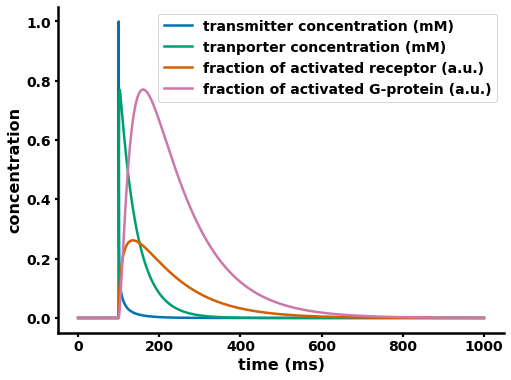

In [22]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Tvar, label="transmitter concentration (mM)")
plt.plot(t_vec, Bvar, label="tranporter concentration (mM)")
plt.plot(t_vec, Rvar, label="fraction of activated receptor (a.u.)")
plt.plot(t_vec, Gvar, label="fraction of activated G-protein (a.u.)")
plt.xlabel('time (ms)')
plt.ylabel('concentration')
plt.legend()
plt.show()

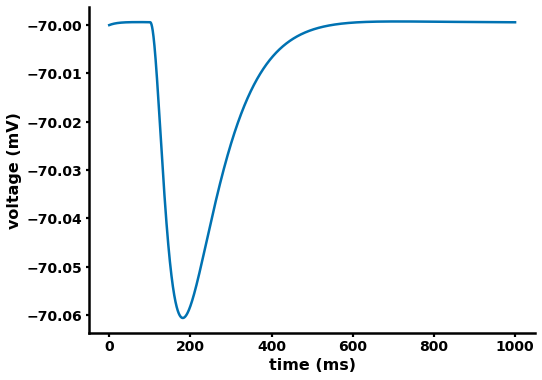

In [23]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.show()

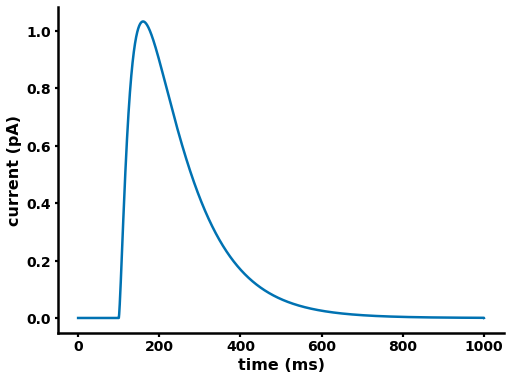

In [24]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn)
plt.xlabel('time (ms)')
plt.ylabel('current (pA)')
plt.show()

In [25]:
pre_spikes = [100]  # list with presynaptic spikes (ms)

gbar = 1/22  # maximum conductance (nS) --  we reduce the maximum condactance to have almost the same response.
E_syn = -95  # synaptic reversal potential (mV)
tau_rise = 40  # rise time (ms)
tau_decay = 100  # decay time (ms)

In [26]:
# Membrane voltage
V = np.zeros((len(t_vec), ))
V[0] = EL  # initialization at EL

# Adaptation current
w = np.zeros((len(t_vec), ))
w[0] = 0  # initialization at 0

# synaptic conductance
gsyn = np.zeros((len(t_vec), ))
gsyn[0] = 0  # initialization at 0

# rise variable
xsyn = np.zeros((len(t_vec), ))
xsyn[0] = 0  # initialization at 0

# Synaptic current
Isyn2 = np.zeros((len(t_vec), ))

# Helper variables
tspike = [-1]
flag = True

for n in range(steps):

  # Compute `Isyn2[n+1]`
  Isyn2[n] = gsyn[n]*(V[n] - E_syn)
  
  # Compute `dV` and update `V[n+1]`
  dV = (-gL*(V[n]-EL) + gL*DeltaT*np.exp((V[n]-VT)/DeltaT) - w[n] - Isyn2[n])/C
  V[n+1] = V[n] + dt*dV

  # Compute `dw` and update `w[n+1]`
  dw = (alpha*(V[n]-EL) - w[n])/tau_w
  w[n+1] = w[n] + dt*dw

  # Compute `dgsyn` and `dxsyn` and update `gsyn[n+1]` and `xsyn[n+1]`
  dgsyn = -gsyn[n]/tau_decay + xsyn[n]
  dxsyn = -xsyn[n]/tau_rise
  gsyn[n+1] = gsyn[n] + dt*dgsyn
  xsyn[n+1] = xsyn[n] + dt*dxsyn

  # Spike mechanism
  if V[n+1] > Vpeak and flag:
    tspike.append(n*dt)
    V[n+1] = Vr
    w[n+1] += b
    flag = False

  # Refractory
  if not flag:
    V[n+1] = Vr

  # End of refractory
  if n*dt > tref + tspike[-1]:
    flag = True

  # Presynaptic spike
  if n in [int(j/dt) for j in pre_spikes]:
    xsyn[n+1] += gbar*normalize(tau_rise, tau_decay)

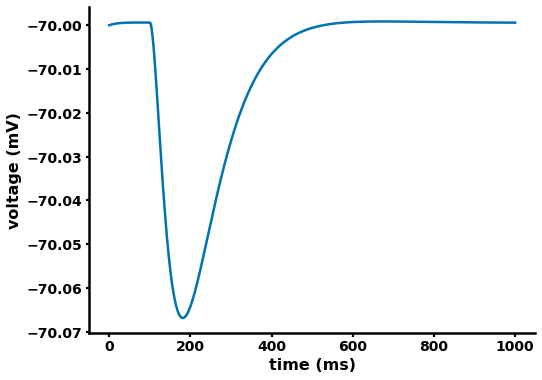

In [27]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, V)
plt.xlabel('time (ms)')
plt.ylabel('voltage (mV)')
plt.show()

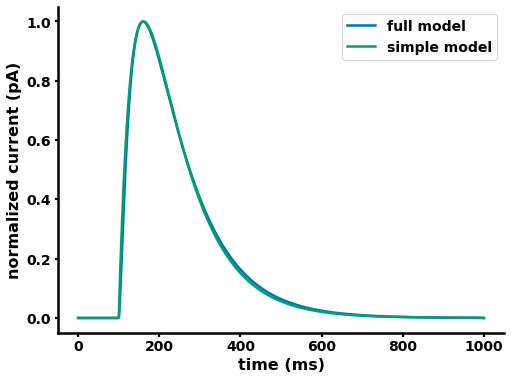

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(t_vec, Isyn/np.max(Isyn), label='full model')
plt.plot(t_vec, Isyn2/np.max(Isyn2), label='simple model')
plt.xlabel('time (ms)')
plt.ylabel('normalized current (pA)')
plt.legend()
plt.show()

In [29]:
print(f"The Root Mean Squared Error (RMSE): {np.sqrt((1/len(Isyn))*np.sum((Isyn-Isyn2)**2))}")

The Root Mean Squared Error (RMSE): 0.04031045288731268


# Appendix: Chemical reactions into differential equations

Generally speaking, when we have:

If the chemical reaction is:

\begin{equation}
A {\stackrel{k}{\rightarrow}} B
\end{equation}

then, the differential equations are:

\begin{align}
\frac{d[A]}{dt} &= -k \cdot [A] \\
\frac{d[B]}{dt} &= k \cdot [A]
\end{align}

<br>

If the chemical reaction is:

\begin{equation}
A \underset{k_2}{\stackrel{k_1}{\rightleftharpoons}} B
\end{equation}

then, the differential equations are:

\begin{align}
\frac{d[A]}{dt} &= -k_1 \cdot [A] + k_2\cdot[B] \\
\frac{d[B]}{dt} &= k_1 \cdot [A] - k_2\cdot[B] \\
\end{align}

<br>

If the chemical reaction is:

\begin{equation}
A + B \underset{k_2}{\stackrel{k_1}{\rightleftharpoons}} C
\end{equation}

then, the differential equations are:

\begin{align}
\frac{d[A]}{dt} &= -k_1 \cdot [A]\cdot [B] + k_2\cdot[C] \\
\frac{d[B]}{dt} &= -k_1 \cdot [A]\cdot[B] + k_2\cdot[C] \\
\frac{d[C]}{dt} &= k_1 \cdot [A]\cdot[B] - k_2\cdot[C]
\end{align}

<br>

If the chemical reaction is:

\begin{equation}
A + B {\stackrel{k}{\rightarrow}} C
\end{equation}

then, the differential equations are:

\begin{align}
\frac{d[A]}{dt} &= -k \cdot [A]\cdot [B] \\
\frac{d[B]}{dt} &= -k \cdot [A]\cdot[B] \\
\frac{d[C]}{dt} &= k \cdot [A]\cdot[B]
\end{align}